Using device: cuda


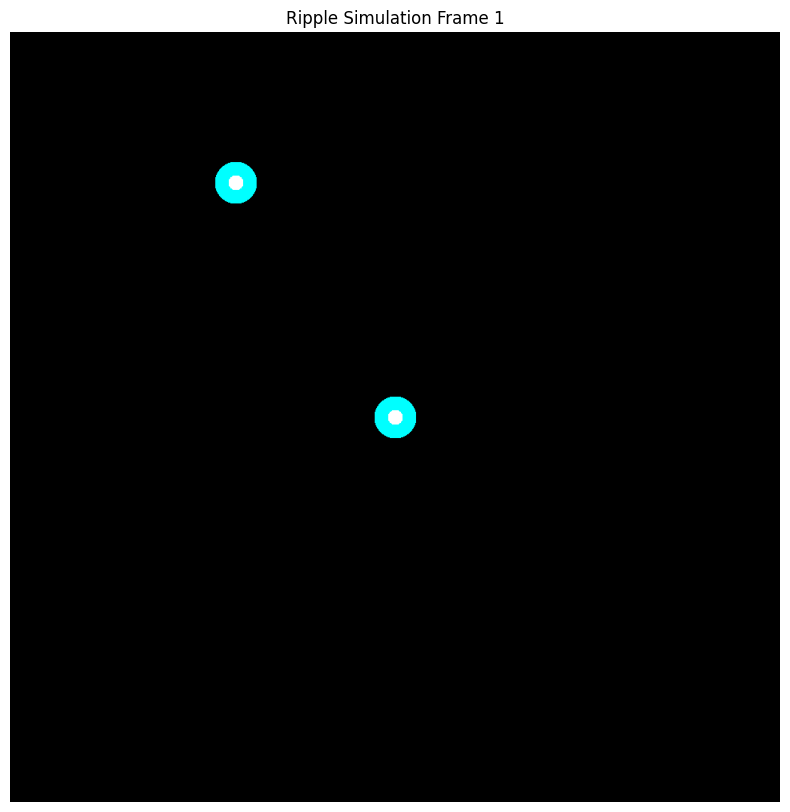

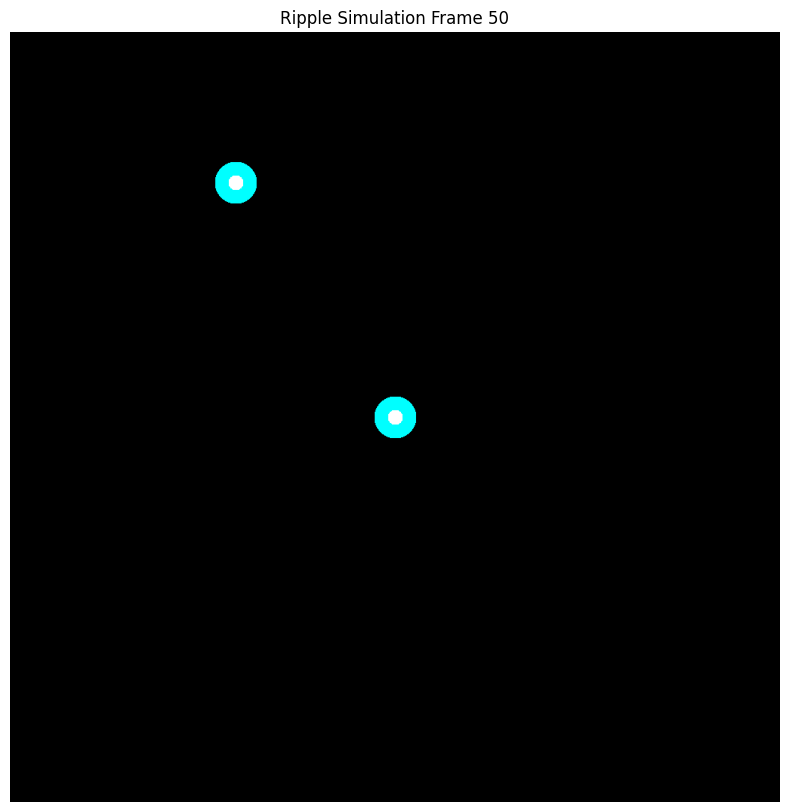

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from time import time

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Grid Dimensions (Example: 1024x1024 = ~1M agents)
GRID_SIZE = 1024

# Global Parameters
R_CORE = 10
R_MID = 28
LAMBDA = 0.08
MU = 0.025
OMEGA = 0.12
K = 0.18
ALPHA = 0.12
THETA_WRITE = 0.12
THETA_ROUTE = 0.38
THETA_FORGET = 0.25
DELTA_FAST = 0.009
DELTA_SLOW = 0.00004

# Initialize State Tensors
role = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.int32, device=device)
energy = torch.ones((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device)
memory = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device)
memoryAccess = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.int32, device=device)
memoryOutcome = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device)
taskLoad = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device)
taskId = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.int32, device=device)
rippleIntensity = torch.zeros((GRID_SIZE, GRID_SIZE), dtype=torch.float32, device=device)

# Coordinate Grids for distance math
y_coords, x_coords = torch.meshgrid(torch.arange(GRID_SIZE, device=device), torch.arange(GRID_SIZE, device=device), indexing='ij')

class RippleSimulation:
    def __init__(self, size):
        self.size = size
        self.frame = 0
        self.active_tasks = [] # List of (y, x, start_frame)

    def add_task(self, y, x):
        self.active_tasks.append({'pos': (y, x), 'start': self.frame})

    def update_roles_and_ripples(self):
        global role, rippleIntensity
        rippleIntensity.fill_(0.0)
        role.fill_(2) # Default to SHELL

        if not self.active_tasks:
            return

        for task in self.active_tasks:
            ty, tx = task['pos']
            dt = float(self.frame - task['start'])
            dist = torch.sqrt((x_coords - tx)**2 + (y_coords - ty)**2)
            role[dist < R_MID] = 1 # MID
            role[dist < R_CORE] = 0 # CORE
            incoming = torch.exp(-LAMBDA * dist) * torch.exp(torch.tensor(-MU * dt, device=device)) * torch.cos(OMEGA * dt - K * dist)
            incoming = torch.clamp(incoming, min=0.0)
            rippleIntensity = rippleIntensity + incoming - (rippleIntensity * incoming)

    def step(self):
        global energy, memory, taskLoad, memoryAccess
        self.update_roles_and_ripples()
        is_core = (role == 0)
        taskLoad[is_core] = torch.clamp(taskLoad[is_core] + 0.05, 0, 1)
        energy[is_core] = torch.clamp(energy[is_core] - 0.01, 0, 1)
        is_mid = (role == 1)
        kernel = torch.ones((1, 1, 3, 3), device=device) / 9.0
        smoothed_load = F.conv2d(taskLoad.unsqueeze(0).unsqueeze(0), kernel, padding=1).squeeze()
        taskLoad[is_mid] = smoothed_load[is_mid]
        energy[is_mid] -= 0.002 * taskLoad[is_mid]
        is_shell = (role == 2)
        write_mask = is_shell & (rippleIntensity > THETA_WRITE)
        memory[write_mask] += ALPHA * rippleIntensity[write_mask] * (1.0 - memory[write_mask])
        memoryAccess[write_mask] = self.frame
        time_diff = (self.frame - memoryAccess).float()
        recency = torch.clamp(1.0 - (time_diff * 0.0005), min=0.0)
        utility = 0.6 * memoryOutcome + 0.4 * recency
        prune_fast = is_shell & (utility < THETA_FORGET)
        prune_slow = is_shell & (utility >= THETA_FORGET)
        memory[prune_fast] -= DELTA_FAST * memory[prune_fast]
        memory[prune_slow] -= DELTA_SLOW * memory[prune_slow]
        self.frame += 1

    def render(self):
        img = torch.zeros((self.size, self.size, 3), device=device)
        img[role == 2, 0] = memory[role == 2]
        img[role == 2, 2] = memory[role == 2]
        img[role == 1, 1] = 1.0
        img[role == 1, 2] = 1.0
        img[role == 0, :] = 1.0
        plt.figure(figsize=(10, 10))
        plt.imshow(img.cpu().numpy())
        plt.axis('off')
        plt.title(f'Ripple Simulation Frame {self.frame}')
        plt.show()

sim = RippleSimulation(GRID_SIZE)
sim.add_task(512, 512)
sim.add_task(200, 300)

for i in range(50):
    sim.step()
    if i % 49 == 0:
        sim.render()

In [1]:
import torch
if torch.cuda.is_available():
    print(f'Success! Found GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB')
else:
    print('GPU not detected. Please go to Runtime > Change runtime type and select a GPU accelerator.')

Success! Found GPU: Tesla T4
Memory Allocated: 0.00 MB
